# 1. Análisis Exploratorio de Datos (EDA)

## Objetivo
Comprender la composición del dataset "Doctor Maíz", identificar problemas potenciales (como desbalance o sesgos de captura) y justificar las decisiones de preprocesamiento, aumento de datos y entrenamiento del modelo MobileNetV3.

## 1.1 Documentación general del dataset
* **Número total de imágenes:** [Escribe el total aquí, ej. 18,500]
* **Número de clases:** [Escribe el número de clases final, ej. 9]
* **Descripción de clases:** El dataset abarca enfermedades foliares (ej. Gray Leaf Spot, Northern Corn Leaf Blight, Common Rust), plagas (ej. Fall Armyworm, Aphids), deficiencias nutricionales (Nitrógeno, Fósforo, Potasio) y hojas saludables.
* **Procedencia:** Combinación de datasets públicos y capturas propias, divididas en entornos controlados (Laboratorio) y capturas in-situ (Campo/Real).
* **Condiciones de captura:** Existe una alta variabilidad de iluminación y fondos. Las imágenes de laboratorio presentan fondos uniformes y condiciones controladas, mientras que las de campo incluyen ruido visual, luz solar directa, sombras y elementos externos.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import random

try:
    from google.colab import drive
    _HAS_COLAB = True
except ImportError:
    drive = None
    _HAS_COLAB = False

# Montar Drive solo si estamos en Colab y el servicio existe
if _HAS_COLAB:
    try:
        drive.mount('/content/drive', force_remount=False)
    except Exception:
        pass

# Ruta del dataset configurable desde .env o con fallback local
DATASET_ROOT = os.getenv('DATASET_ROOT', '/home/desarrolloab/Documentos/ML/maize_dataset')
DATA_DIR = os.path.join(DATASET_ROOT, 'clean')

if os.path.exists(DATA_DIR):
    print(f"Usando dataset desde: {DATA_DIR}")
else:
    print(f"Advertencia: la ruta no existe: {DATA_DIR}")

# Verificar clases dinámicamente
class_names = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
print(f"Clases a analizar ({len(class_names)}): {class_names}")

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")

Usando dataset desde: /home/desarrolloab/Documentos/ML/maize_dataset/clean
Clases a analizar (9): ['fall_armyworm', 'potassium_deficiency', 'phosphorus_deficiency', 'healthy', 'common_rust', 'northern_corn_leaf_blight', 'gray_leaf_spot', 'aphids_pest', 'nitrogen_deficiency']


## 1.2 Análisis de distribución de clases
Es fundamental identificar si el conjunto de datos presenta un desbalance significativo. Un desbalance severo puede provocar que el modelo se sesgue hacia la clase mayoritaria (ej. Healthy), ignorando las enfermedades menos representadas. Identificar esto justificará el uso de técnicas como la ponderación de clases (`class_weights`) durante el entrenamiento.

/tmp/ipykernel_47979/1282876898.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(x='Cantidad', y='Clase', data=df_conteos, palette='viridis')


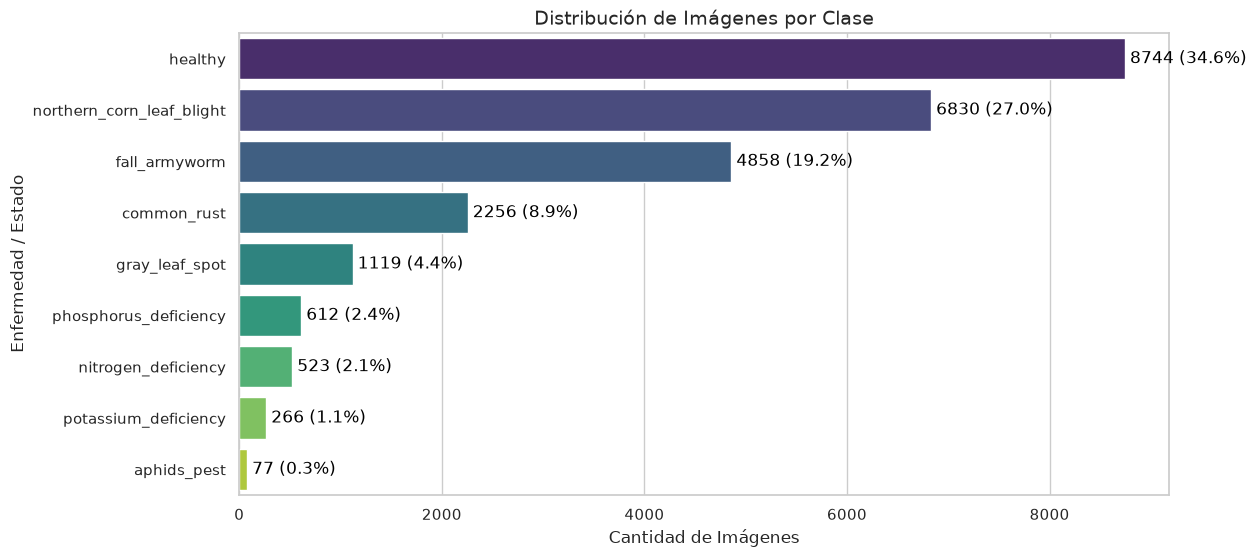

In [2]:
conteos = {}
total_imagenes = 0

for clase in class_names:
    ruta_clase = os.path.join(DATA_DIR, clase)
    # Contamos todos los archivos, incluso si están dentro de subcarpetas (lab/real)
    cantidad = sum([len(files) for r, d, files in os.walk(ruta_clase)])
    conteos[clase] = cantidad
    total_imagenes += cantidad

df_conteos = pd.DataFrame(list(conteos.items()), columns=['Clase', 'Cantidad'])
df_conteos = df_conteos.sort_values(by='Cantidad', ascending=False)
df_conteos['Porcentaje'] = (df_conteos['Cantidad'] / total_imagenes) * 100

plt.figure(figsize=(12, 6))
grafico = sns.barplot(x='Cantidad', y='Clase', data=df_conteos, palette='viridis')

for index, row in enumerate(df_conteos.itertuples()):
    grafico.text(row.Cantidad + 50, index, f"{int(row.Cantidad)} ({row.Porcentaje:.1f}%)", color='black', va="center")

plt.title('Distribución de Imágenes por Clase', fontsize=14)
plt.xlabel('Cantidad de Imágenes')
plt.ylabel('Enfermedad / Estado')
plt.show()

## 1.3 Análisis de origen de las imágenes (Lab vs Real)
La procedencia de la imagen introduce un riesgo de *Data Leakage* o atajos de aprendizaje. Si una enfermedad específica tiene el 95% de sus imágenes tomadas en laboratorio con un fondo blanco, la red neuronal podría aprender a identificar el "fondo blanco" en lugar del patógeno real.

Analizando el origen de las imágenes (Lab vs Real)...


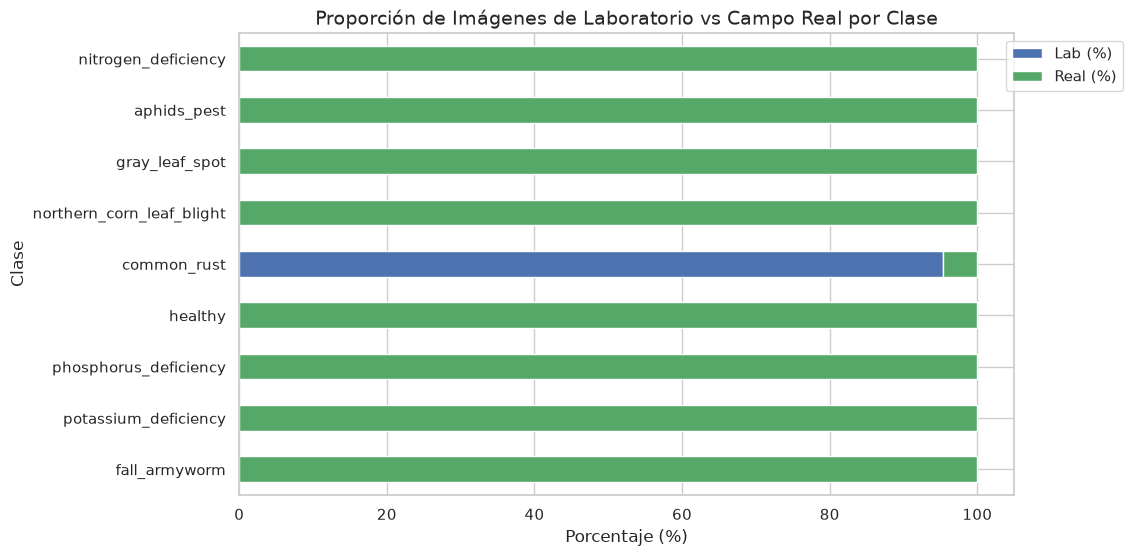

In [3]:
print("Analizando el origen de las imágenes (Lab vs Real)...")

origen_datos = []

for clase in class_names:
    ruta_clase = os.path.join(DATA_DIR, clase)
    cant_lab = 0
    cant_real = 0

    # Recorremos todos los archivos de la clase
    for root, dirs, files in os.walk(ruta_clase):
        for file in files:
            nombre_archivo = file.lower()

            # Buscamos la etiqueta en el nombre del archivo o en la ruta
            if 'lab' in nombre_archivo or '/lab/' in root.lower():
                cant_lab += 1
            elif 'real' in nombre_archivo or '/real/' in root.lower():
                cant_real += 1
            else:
                # Si no especifica, asumimos que es una captura normal de campo (real)
                cant_real += 1

    total = cant_lab + cant_real

    # Solo agregamos si encontró imágenes para evitar el KeyError
    if total > 0:
        origen_datos.append({
            'Clase': clase,
            'Lab (%)': (cant_lab / total) * 100,
            'Real (%)': (cant_real / total) * 100
        })

# Ahora la lista sí tiene datos, podemos crear el DataFrame sin problemas
df_origen = pd.DataFrame(origen_datos).set_index('Clase')

df_origen.plot(kind='barh', stacked=True, figsize=(10, 6), color=['#4C72B0', '#55A868'])
plt.title('Proporción de Imágenes de Laboratorio vs Campo Real por Clase', fontsize=14)
plt.xlabel('Porcentaje (%)')
plt.ylabel('Clase')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.show()

## 1.4 Análisis de resolución y dimensiones
Las redes neuronales convolucionales requieren tensores de entrada con dimensiones fijas (en nuestro caso, 224x224 píxeles para MobileNetV3). Conocer las dimensiones originales nos ayuda a entender cuánta información se perderá o distorsionará durante el redimensionamiento (*resizing*).

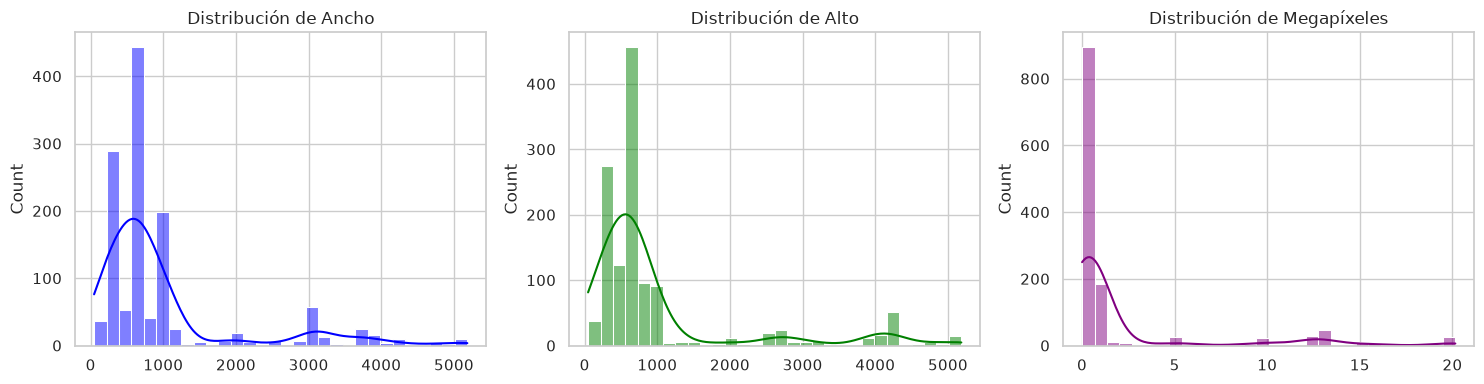

In [4]:
# Muestreo para no saturar memoria
MUESTRA = 150
anchos, altos, megapixeles = [], [], []

for clase in class_names:
    rutas = []
    for root, dirs, files in os.walk(os.path.join(DATA_DIR, clase)):
        for file in files:
            rutas.append(os.path.join(root, file))

    muestra = random.sample(rutas, min(len(rutas), MUESTRA))

    for ruta in muestra:
        img = cv2.imread(ruta)
        if img is not None:
            h, w, _ = img.shape
            anchos.append(w)
            altos.append(h)
            megapixeles.append((w * h) / 1000000)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.histplot(anchos, bins=30, kde=True, color='blue')
plt.title('Distribución de Ancho')

plt.subplot(1, 3, 2)
sns.histplot(altos, bins=30, kde=True, color='green')
plt.title('Distribución de Alto')

plt.subplot(1, 3, 3)
sns.histplot(megapixeles, bins=30, kde=True, color='purple')
plt.title('Distribución de Megapíxeles')

plt.tight_layout()
plt.show()

## 1.5 Análisis de calidad de imagen (Brillo y Desenfoque)
Se evaluó la exposición y nitidez de las imágenes. Para detectar imágenes borrosas, calculamos la varianza del Laplaciano; valores muy cercanos a cero indican falta de bordes detectables (desenfoque severo). El brillo medio nos indica si existen problemas de subexposición o sobreexposición severa en el dataset.

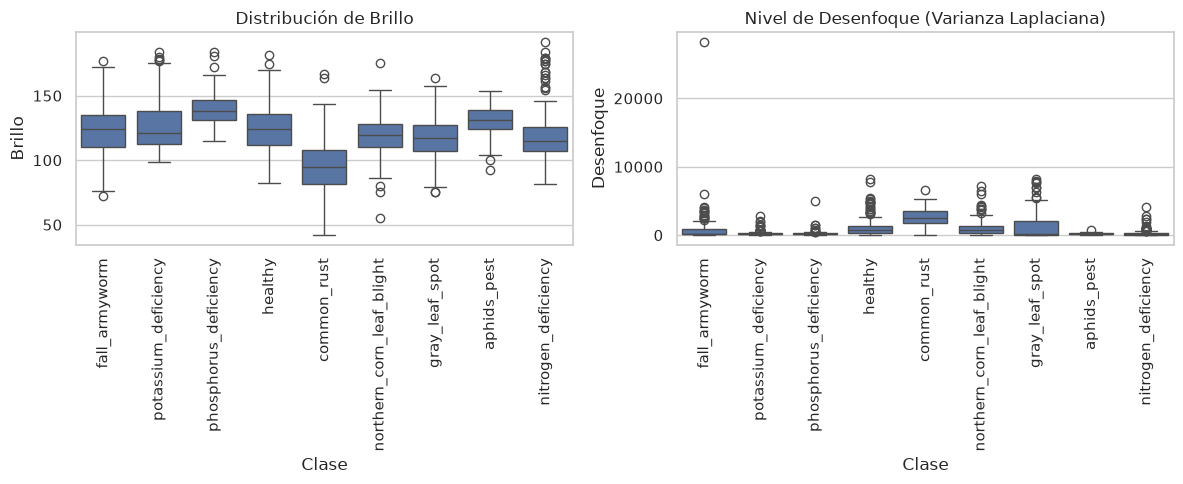

In [5]:
calidad_datos = []

for clase in class_names:
    rutas = []
    for root, dirs, files in os.walk(os.path.join(DATA_DIR, clase)):
        for file in files:
            rutas.append(os.path.join(root, file))

    muestra = random.sample(rutas, min(len(rutas), MUESTRA))

    for ruta in muestra:
        img = cv2.imread(ruta)
        if img is not None:
            gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            # Varianza del Laplaciano (Métrica de qué tan borrosa es)
            laplaciano_var = cv2.Laplacian(gris, cv2.CV_64F).var()
            brillo = np.mean(gris)

            calidad_datos.append({'Clase': clase, 'Desenfoque': laplaciano_var, 'Brillo': brillo})

df_calidad = pd.DataFrame(calidad_datos)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='Clase', y='Brillo', data=df_calidad)
plt.xticks(rotation=90)
plt.title('Distribución de Brillo')

plt.subplot(1, 2, 2)
sns.boxplot(x='Clase', y='Desenfoque', data=df_calidad)
plt.xticks(rotation=90)
plt.title('Nivel de Desenfoque (Varianza Laplaciana)')

plt.tight_layout()
plt.show()

## 1.6 Detección de duplicados y limpieza
Antes del análisis exploratorio final, se aplicó una etapa de limpieza documental y automática para reducir ruido, evitar sobreajuste y evitar fugas de información entre conjuntos.

* **Método utilizado:** el flujo de limpieza del proyecto combina filtros de calidad y detección de duplicados mediante `imagededup` con el algoritmo **PHash**. La idea es identificar imágenes casi idénticas o repetidas aunque presenten ligeras variaciones, y conservar una sola versión representativa por grupo.
* **Criterios de exclusión:** además de los duplicados, se descartaron imágenes procesadas artificialmente (recortes, filtros, augmentaciones), muestras con metadatos inconsistentes, imágenes fuera de clase o con marcas/objetos que no corresponden a la enfermedad, y datasets que mostraron mezcla destructiva entre laboratorio y campo sin trazabilidad clara.
* **Riesgo de data leakage:** en algunos casos se detectó que imágenes de una clase aparecían duplicadas en otras fuentes o que el mismo contenido estaba presente en varios datasets. En el proyecto se documenta explícitamente el caso de `maize-diseases` donde 513 imágenes de GLS fueron detectadas como clones exactos de imágenes ya integradas desde `cropdg`, y también se reporta que el dataset `maize-diseases 1.0` fue descartado por estar completamente contenido en la versión `1.1`.
* **Resultado cuantitativo del proceso:** tras la limpieza, el proyecto reporta aprox. **5,326** imágenes útiles para `maize-diseases 1.1`, **1,872** para `maize_africa`, **1,162** para `cropdg`, **877** para `maize_field` (tras descartar 22 duplicados), y deja a `maize-diseases 1.0` con **0** imágenes útiles porque fue absorbido por la versión más reciente.

## 1.7 Identificación de posibles sesgos (Conclusión del EDA)
A partir de la distribución por clases y del análisis de origen (laboratorio vs campo), se identifican varios sesgos que pueden afectar el entrenamiento:

1. **Desbalance de clases:** algunas enfermedades tienen muchas más imágenes que otras, lo que puede llevar a que el modelo favorezca las clases mayoritarias. En los documentos del proyecto se resalta que la clase de **Roya común** tiene solo alrededor de **399 imágenes de campo real** frente a más de **5,700** para NCLB y más de **5,400** para GLS, lo que sugiere un riesgo claro de sesgo y la necesidad de augmentation específica.
2. **Sesgo por entorno de captura:** las imágenes de laboratorio suelen tener fondos uniformes y condiciones controladas, mientras que las imágenes de campo presentan mayor ruido visual, sombras, iluminación cambiante y elementos distractores. El proyecto advierte que entrenar solo con laboratorio puede llevar a que el modelo aprenda el fondo en lugar de la enfermedad.
3. **Riesgo de dominio y sobreajuste:** cuando el mismo contenido aparece repetido entre datasets o cuando se mezclan imágenes procesadas con originales, el modelo puede parecer mejor de lo que realmente es. Esto se refuerza con los hallazgos documentados sobre duplicados cruzados y datasets descartados por calidad.
4. **Posible sesgo visual externo:** en algunos datasets se observan elementos ajenos a la hoja (tarjetas, marcas, recortes o fondos muy distintos), lo que puede inducir al modelo a asociar detalles no biológicos con la enfermedad.
5. **Implicación práctica para el entrenamiento:** la documentación recomienda priorizar imágenes de campo real en la evaluación y, para la clase de Roya común, alcanzar al menos **2,000 imágenes de campo real** antes de la adaptación de dominio, usando augmentation para compensar la escasez.
